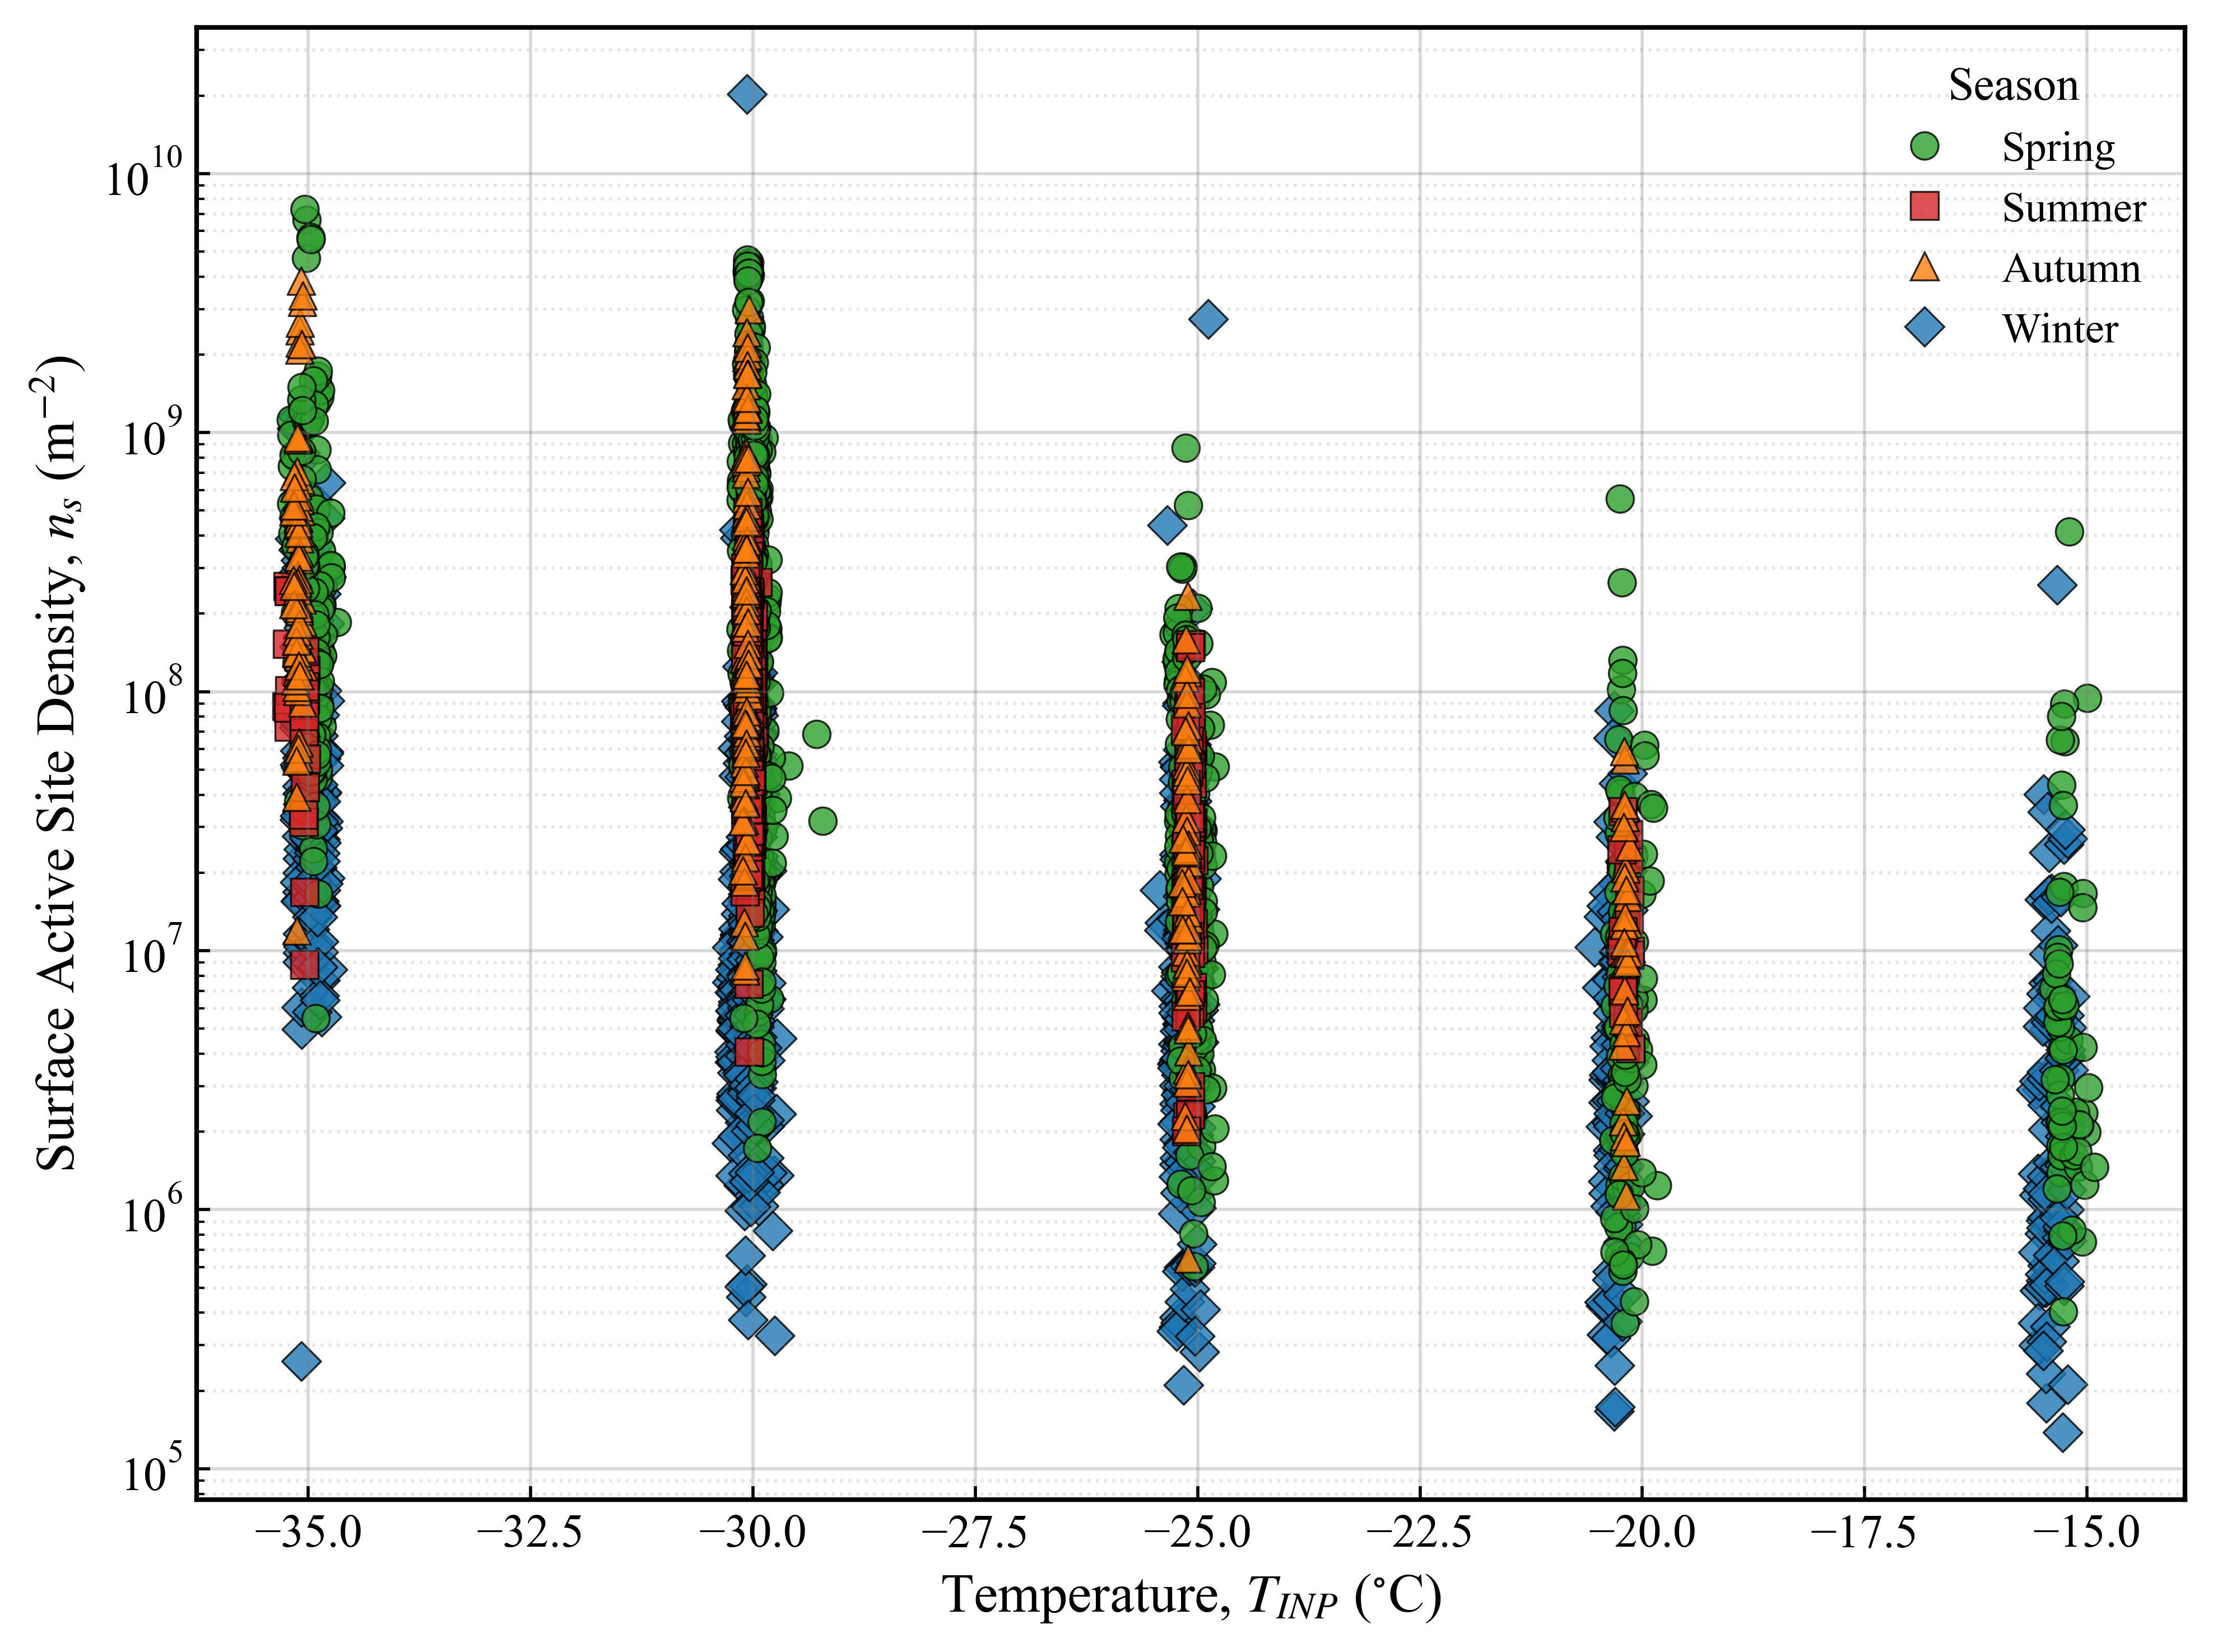

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. 模拟数据（替换为你自己的 DataFrame）
# ==========================================
df = pd.read_csv(r"D:\Coding\Data\Lanzhou_aerosol\SMPS+APS\INP+ns(outer).csv", parse_dates=['Date'])

# ==========================================
# 1. 全局学术图表样式设置
# ==========================================
config = {
    "font.family": "serif",
    "font.serif": ["Times New Roman"], # 毕业论文常用字体，若无此字体可注释掉
    "mathtext.fontset": "stix",        # 公式字体风格
    "axes.labelsize": 14,              # 坐标轴标签字体大小
    "xtick.labelsize": 12,             # 刻度字体大小
    "ytick.labelsize": 12,
    "legend.fontsize": 11,             # 图例字体大小
    "legend.title_fontsize": 12,
    "axes.linewidth": 1.2,             # 坐标轴线宽
    "figure.dpi": 500                  # 高分辨率，适合论文
}
plt.rcParams.update(config)
# ==========================================
# 2. 定义颜色和形状映射
# ==========================================
# 定义符合季节直觉的颜色 (春绿, 夏红, 秋橙, 冬蓝)
season_colors = {
    'Spring': '#2ca02c', 
    'Summer': '#d62728', 
    'Autumn': '#ff7f0e', 
    'Winter': '#1f77b4'
}
# 定义不同形状，防止黑白打印时无法区分
season_markers = {
    'Spring': 'o', # 圆圈
    'Summer': 's', # 方块
    'Autumn': '^', # 三角
    'Winter': 'D'  # 菱形
}

# ==========================================
# 3. 开始绘图
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

# 使用 seaborn 绘制散点图
sns.scatterplot(
    data=df, 
    x='T_inp(°C)', 
    y='n_s', 
    hue='season',      # 按季节区分颜色
    style='season',    # 按季节区分形状
    hue_order=['Spring', 'Summer', 'Autumn', 'Winter'],  # 确保图例顺序
    palette=season_colors,
    markers=season_markers,
    s=50,              # 点的大小
    alpha=0.8,         # 透明度，防止点密集时重叠看不清
    edgecolor='k',     # 散点边缘加黑色细边框，提升质感(重点)
    linewidth=0.5,
    ax=ax
)
sns.stripplot(
    data=df, x='T_inp(°C)', y='n_s', hue='season',
    jitter=0.2, # 让点在水平方向稍微散开，避免重叠
    dodge=True, # 按季节并排显示
    # 其他参数不变...
)
# ==========================================
# 4. 坐标轴与细节调整
# ==========================================
# Y轴设置为对数坐标 (极其重要)
ax.set_yscale('log')

# 设置规范的坐标轴标签 (支持 LaTeX 语法)
ax.set_xlabel(r'Temperature, $T_{INP}$ ($^{\circ}$C)')
ax.set_ylabel(r'Surface Active Site Density, $n_s$ ($\mathrm{m}^{-2}$)')
ax.tick_params(direction='in', which='both')
# 添加网格线 (主网格实线，次网格虚线，便于对数坐标的读取)
ax.grid(True, which='major', linestyle='-', alpha=0.3, color='grey')
ax.grid(True, which='minor', linestyle=':', alpha=0.2, color='grey')

# 调整图例位置与样式
# frameon=False 去掉图例的边框
ax.legend(title='Season', loc='upper right', frameon=False)

plt.tight_layout() # 自动调整边缘空白

# ==========================================
# 5. 保存图表 
# ==========================================
# plt.savefig('ns_vs_T_plot.pdf', format='pdf', bbox_inches='tight')
#plt.savefig('ns_vs_T_plot.png', dpi=500, bbox_inches='tight')

plt.show()

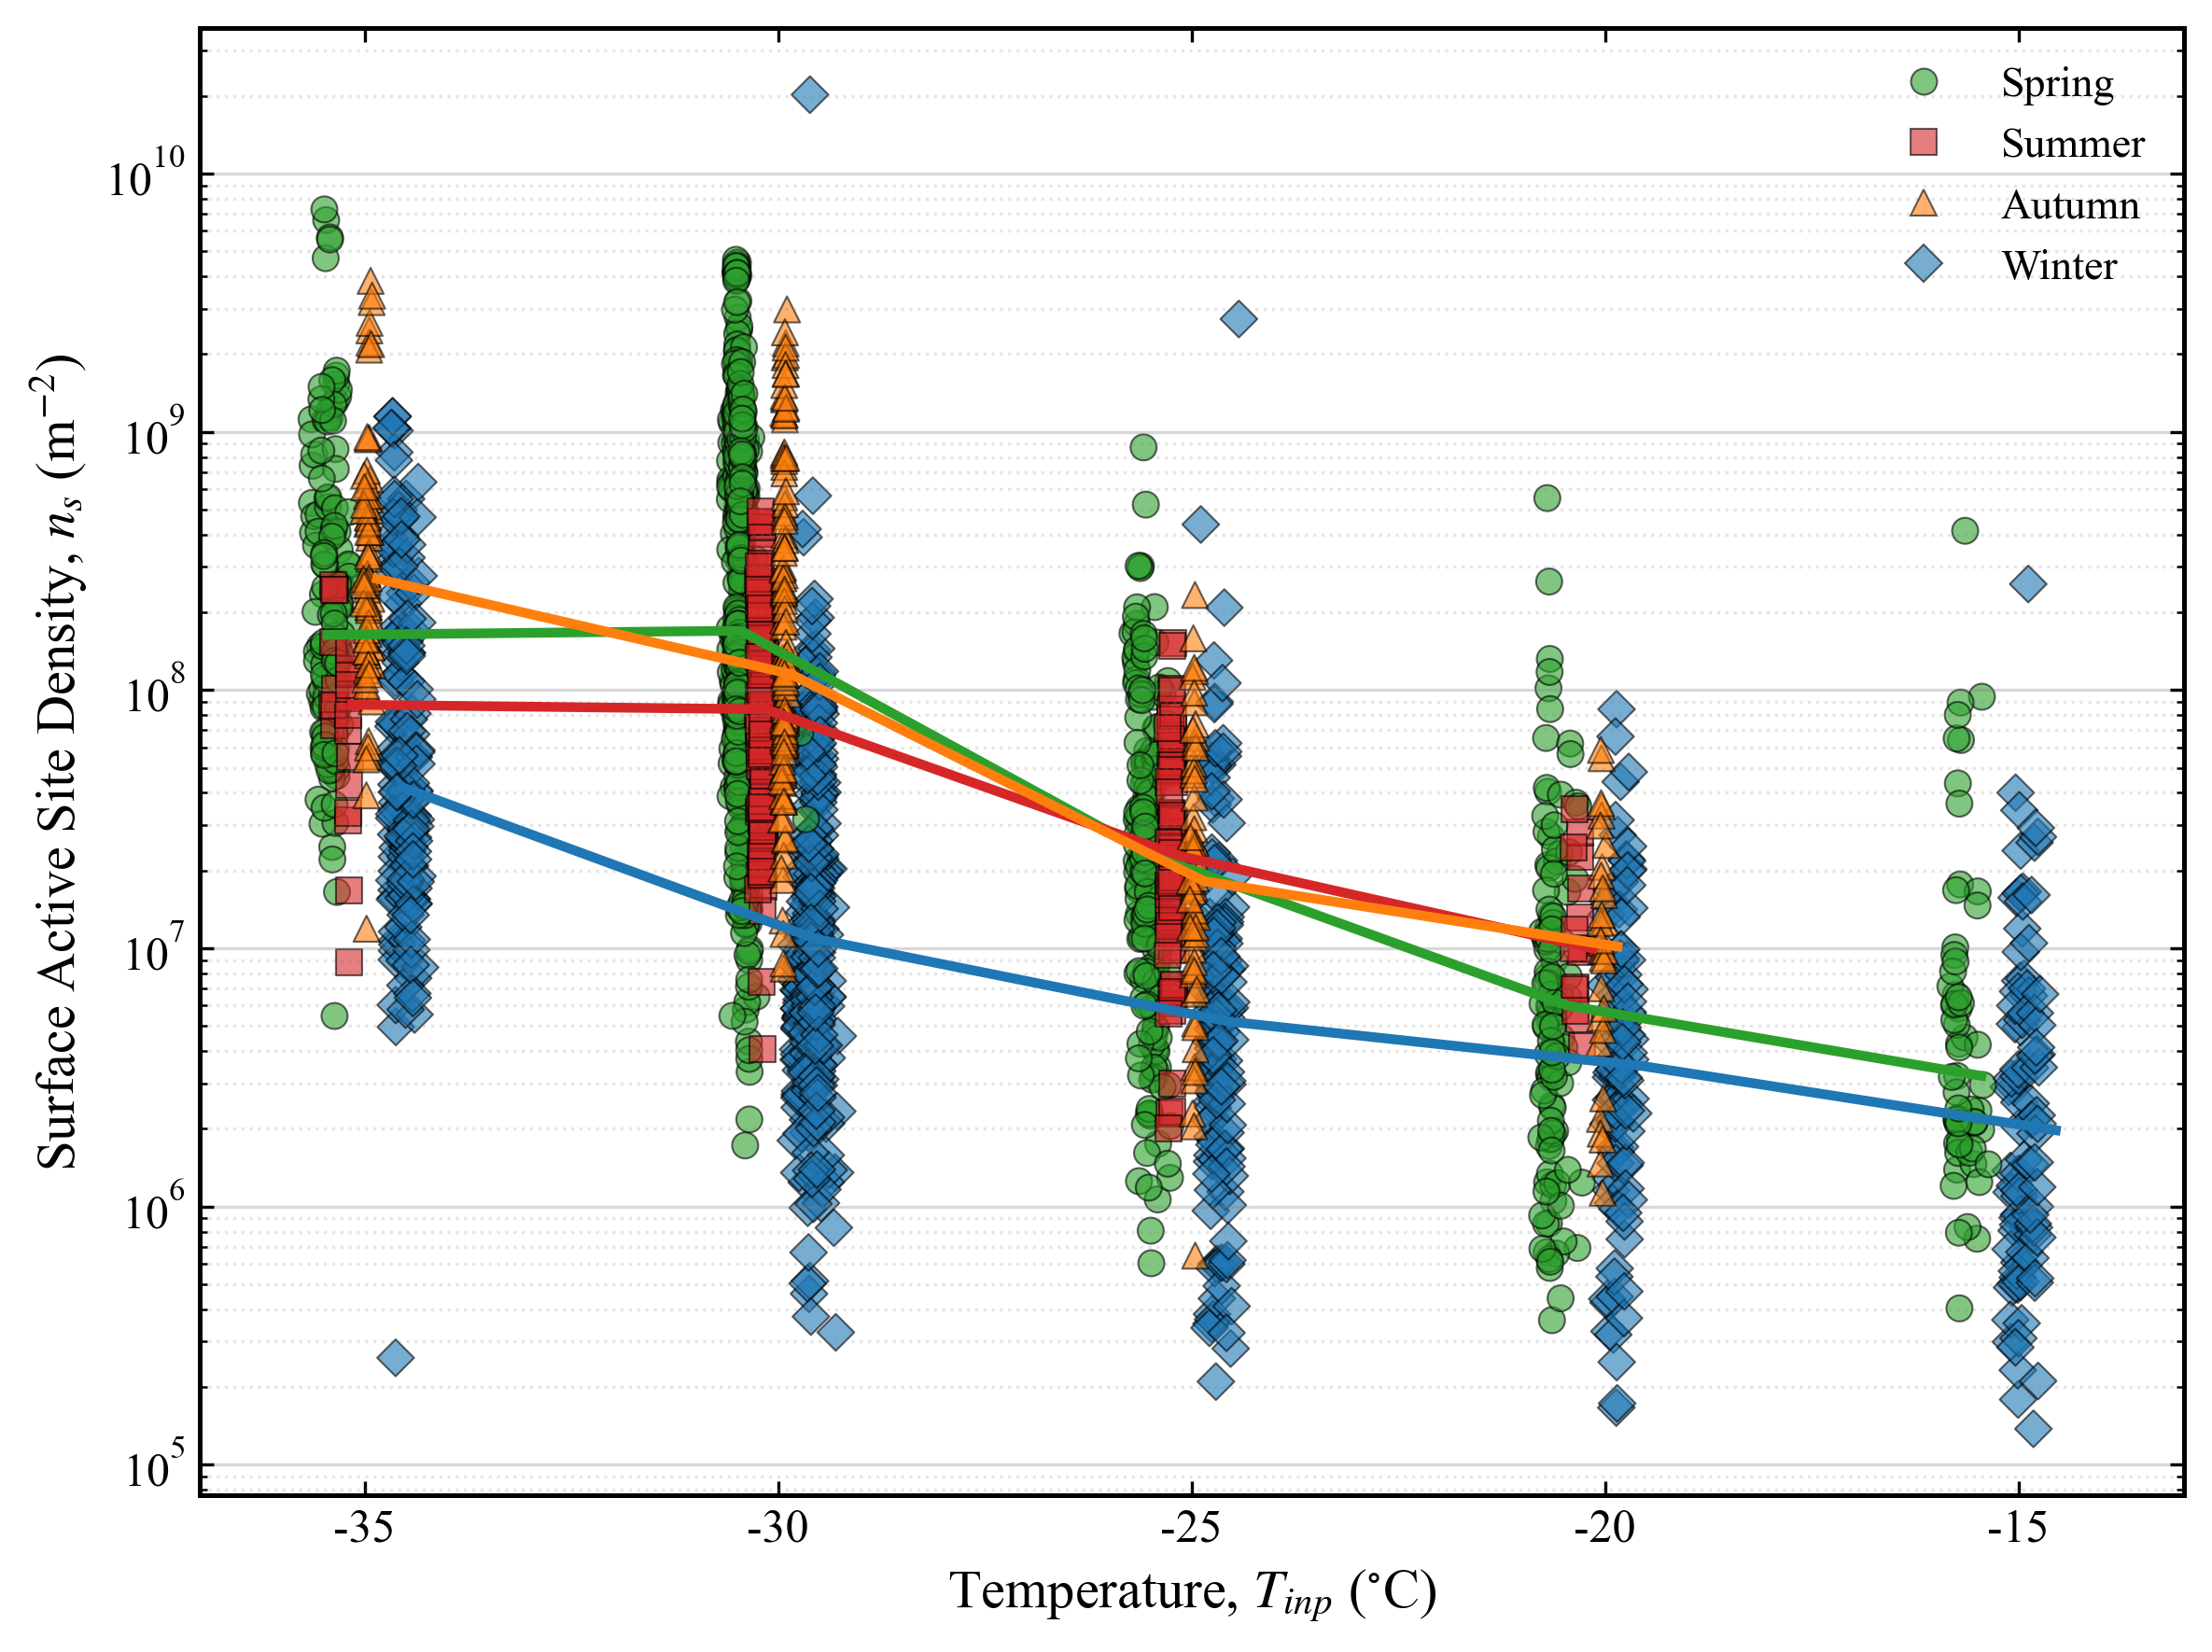

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. 读取数据
# ==========================================

temp_levels = [-35, -30, -25, -20, -15]
df = pd.read_csv(r"D:\Coding\Data\Lanzhou_aerosol\SMPS+APS\INP+ns(outer).csv", parse_dates=['Date'])

# ==========================================
# 1. 核心操作：手动设置 X 轴偏移量 (Dodge)
# ==========================================
# 我们给每个季节人为加上一点点温度偏移，让它们在 X 轴上错开
# 偏移量可以根据你的图幅自行微调 (这里设为相差 0.3 度)
offset_dict = {
    'Spring': -0.45, 
    'Summer': -0.15, 
    'Autumn':  0.15, 
    'Winter':  0.45
}
# 创建一个专门用于绘图的 X 坐标列
df['T_plot'] = df['T_inp(°C)'] + df['season'].map(offset_dict)

# ==========================================
# 2. 样式设置
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"], 
    "mathtext.fontset": "stix",        
    "axes.labelsize": 14,              
    "xtick.labelsize": 12,             
    "ytick.labelsize": 12,
    "legend.fontsize": 11,             
    "axes.linewidth": 1.2,             
    "figure.dpi": 300                  
})

season_colors = {'Spring': '#2ca02c', 'Summer': '#d62728', 'Autumn': '#ff7f0e', 'Winter': '#1f77b4'}
season_markers = {'Spring': 'o', 'Summer': 's', 'Autumn': '^', 'Winter': 'D'}
# 强制图例按照春夏秋冬的逻辑顺序排序
season_order = ['Spring', 'Summer', 'Autumn', 'Winter'] 

# ==========================================
# 3. 开始绘图
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

# 使用原本的 scatterplot，但 X 轴用我们加了偏移的 'T_plot'
sns.scatterplot(
    data=df, 
    x='T_plot',      # 注意这里换成了有偏移的坐标
    y='n_s', 
    hue='season',    
    style='season',  
    palette=season_colors,
    markers=season_markers,
    hue_order=season_order,   # 指定颜色顺序
    style_order=season_order, # 指定形状顺序
    s=45,              # 【修改】点调小一点，减少拥挤感
    alpha=0.6,         # 【修改】透明度调低，凸显点密集处的重叠深度
    edgecolor='k',     
    linewidth=0.5,
    ax=ax
)
# 1. 计算每个温度、每个季节的中位数，并画出趋势折线
# 按温度和季节进行分组，算出中位数
df_median = df.groupby(['T_a(°C)', 'season'])['n_s'].median().reset_index()
# 【关键点1】必须按温度排个序，保证画线是从左到右画的，不会来回乱连
df_median = df_median.sort_values(by='T_a(°C)')
# 给这 20 个中位数也加上同样的偏移量，确保折线的折点刚好在散点柱子的正中央
df_median['T_plot'] = df_median['T_a(°C)'] + df_median['season'].map(offset_dict)
# 3. 画趋势折线
sns.lineplot(
    data=df_median,
    x='T_plot', 
    y='n_s', 
    hue='season', 
    hue_order=season_order,
    palette=season_colors,
    linewidth=2.5,      # 线条画粗一点，压住散点
    legend=False,       # 图例散点已经有了，折线不需要重复加
    errorbar=None,      # 关闭默认的误差带（因为我们已经手动求了中位数）
    ax=ax
)

# ==========================================
# 4. 坐标轴与细节调整
# ==========================================
ax.set_yscale('log')

# 设置规范的坐标轴标签
ax.set_xlabel(r'Temperature, $T_{inp}$ ($^{\circ}$C)')
ax.set_ylabel(r'Surface Active Site Density, $n_s$ ($\mathrm{m}^{-2}$)')

# 【非常重要】因为我们用了带偏移的 T_plot 绘图，X轴现在的真实刻度变乱了
# 我们需要强制让 X 轴只显示原始的整数温度刻度！
ax.set_xticks(temp_levels)
ax.set_xticklabels([str(t) for t in temp_levels])
ax.set_xlim(-37, -13) 
ax.tick_params(direction='in', which='both', top=True, right=True)

# 网格线设置
ax.grid(False, axis='x')  # 关掉 X 轴的网格
ax.grid(True, axis='y', which='major', linestyle='-', alpha=0.3, color='grey')
ax.grid(True, axis='y', which='minor', linestyle=':', alpha=0.2, color='grey')

# 图例调整
ax.legend(title='', loc='upper right', frameon=False)

plt.tight_layout() 
#plt.savefig('ns_vs_T_plot_v2.png', dpi=300, bbox_inches='tight')
plt.show()